In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

### EDA - Exploratory Data Analysis

In [30]:
df = sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [32]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [33]:
df_weird = df[(df['x']==0)|(df['y']==0)|(df['z']==0)]
print(df_weird.shape[0]/df.shape[0])
df_weird

0.0003707823507601038


,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


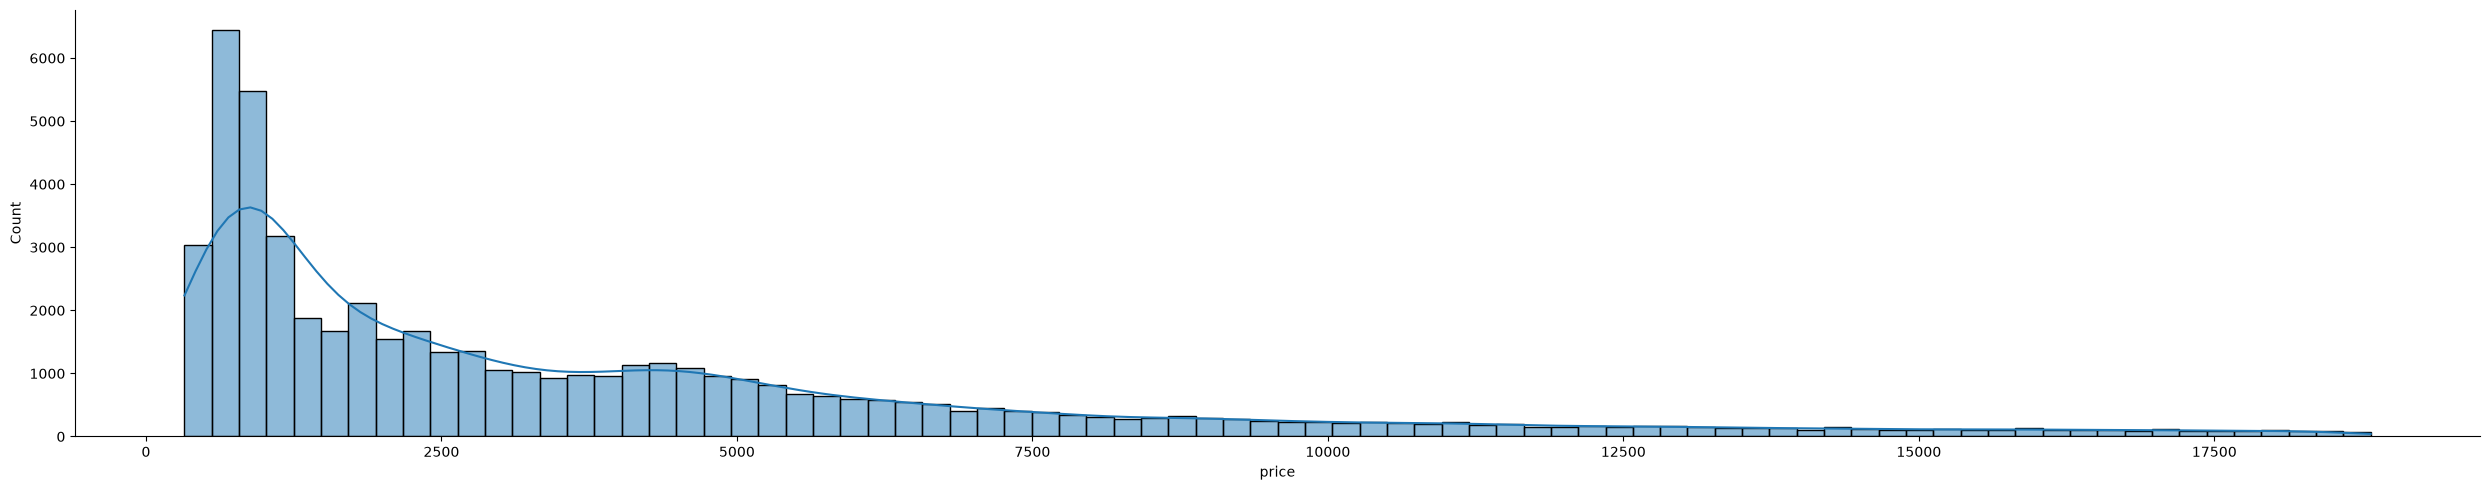

In [34]:
sns.displot(df['price'], kde=True, aspect=5);

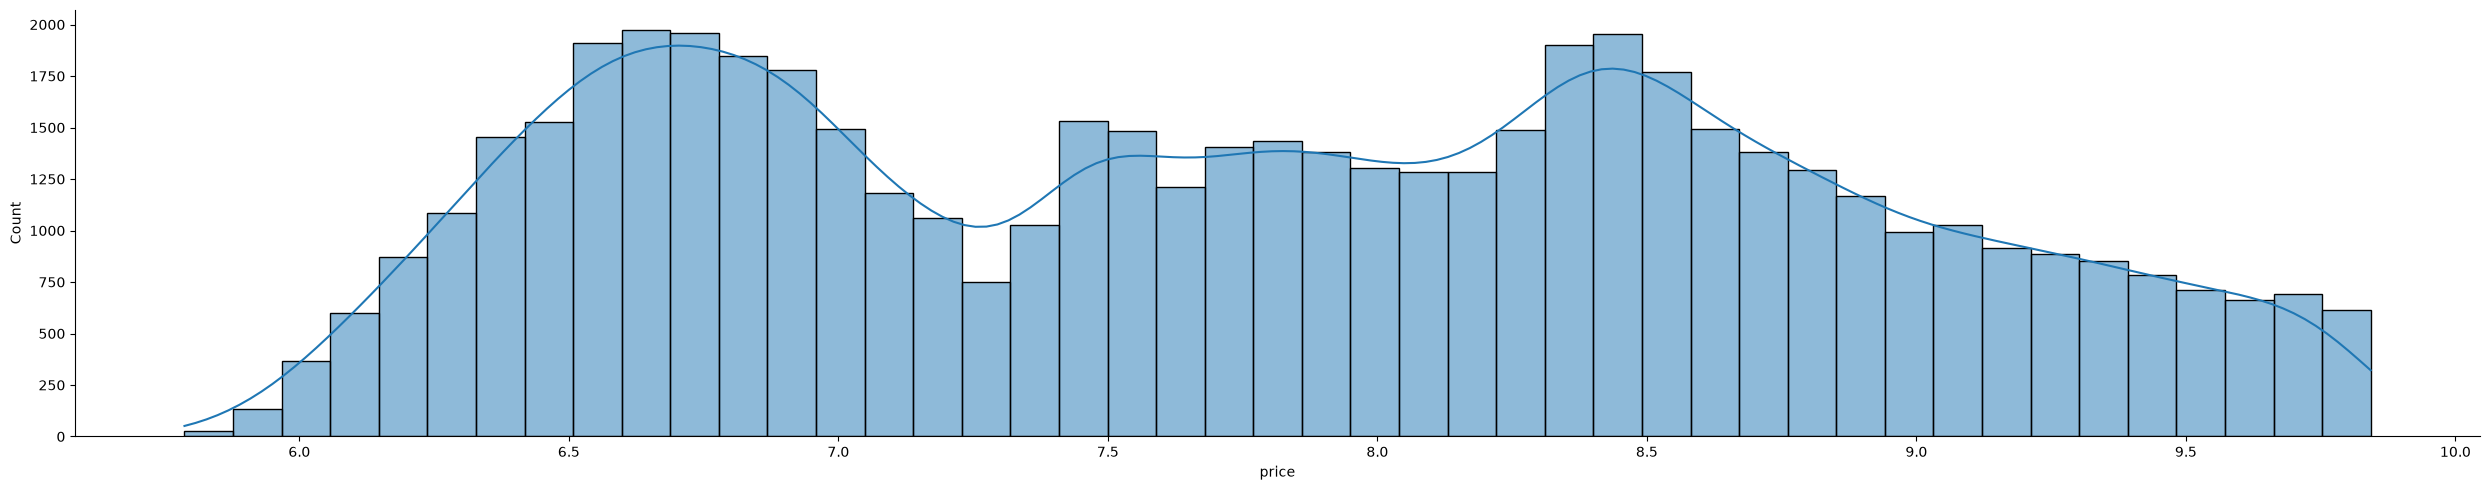

In [35]:
sns.displot(np.log(df['price']), kde=True, aspect=5);

In [36]:
# sns.pairplot(df);

In [37]:
df['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

### Data Cleaning

In [38]:
# clean x,y,z zero values
to_drop = df[(df['x']==0)|(df['y']==0)|(df['z']==0)].index
df.drop(to_drop, inplace=True)

In [39]:
to_drop = df[(df['y']>20)| (df['z']>20)].index
df.drop(to_drop, inplace=True)

In [40]:
# sns.pairplot(df);

### Feature Engineering

In [41]:
# ordinal categorical feature to numerical feature
df['cut_int'] = df['cut'].map({'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}).astype(int)
df['clarity_int'] = df['clarity'].map({'I1':1, 'SI2':2, 'SI1':3, 'VS1':4, 'VS2':5, 'VVS1':6, 'VVS2':7, 'IF':8}).astype(int)

In [42]:
# nominal categorical feature to numerical feature
df = pd.get_dummies(df, columns=['color'], prefix='color')

In [43]:
df['volume'] = df['x'] * df['y'] * df['z']
df['x_y'] = df['x'] / df['y']

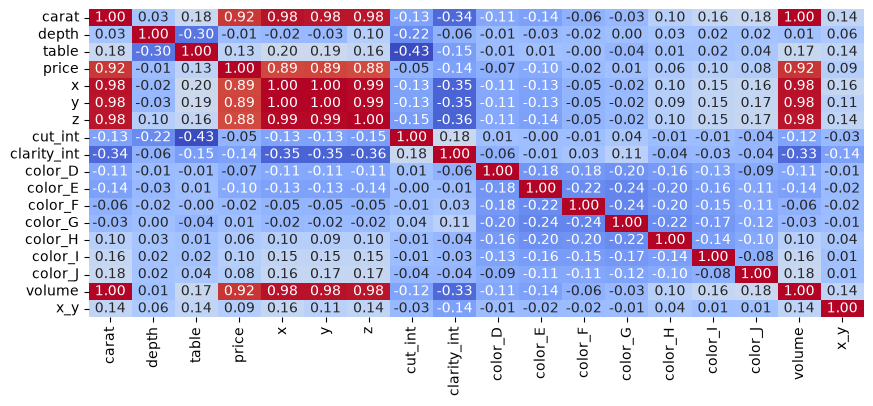

In [44]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm', cbar=False);

In [45]:
X = df.drop(columns=['price', 'cut', 'clarity']) # Features
y = df['price'] # Target variable

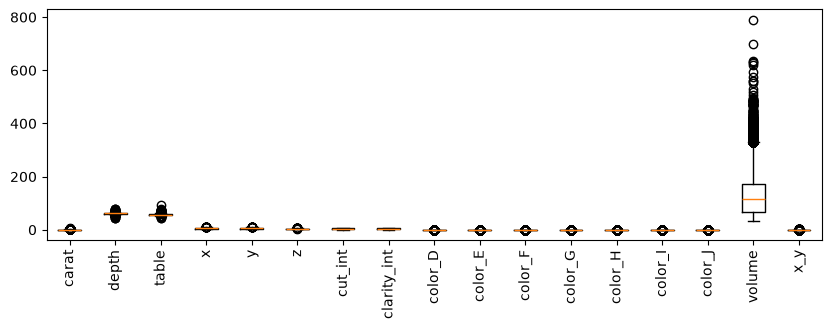

In [46]:
plt.figure(figsize=(10, 3))
plt.boxplot(X)
plt.xticks(range(1, len(X.columns) + 1), X.columns, rotation=90)
plt.show()

### Model Trainning

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
y_train_log = np.log(y_train)

(43133, 17) (10784, 17) (43133,) (10784,)


#### normalization

In [48]:
sc = StandardScaler()
categorical_features = [col for col in X.columns if col.startswith('color_')]
non_categorical_features = [col for col in X.columns if col not in categorical_features]
sc.fit(X_train[non_categorical_features])
X_train[non_categorical_features] = sc.transform(X_train[non_categorical_features])
X_test[non_categorical_features] = sc.transform(X_test[non_categorical_features])

In [49]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 43133 entries, 45779 to 15803
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   carat        43133 non-null  float64
 1   depth        43133 non-null  float64
 2   table        43133 non-null  float64
 3   x            43133 non-null  float64
 4   y            43133 non-null  float64
 5   z            43133 non-null  float64
 6   cut_int      43133 non-null  float64
 7   clarity_int  43133 non-null  float64
 8   color_D      43133 non-null  bool   
 9   color_E      43133 non-null  bool   
 10  color_F      43133 non-null  bool   
 11  color_G      43133 non-null  bool   
 12  color_H      43133 non-null  bool   
 13  color_I      43133 non-null  bool   
 14  color_J      43133 non-null  bool   
 15  volume       43133 non-null  float64
 16  x_y          43133 non-null  float64
dtypes: bool(7), float64(10)
memory usage: 3.9 MB


#### training the model

In [50]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](17,)","[ 631.58, 237.69, 20.25,...,-1506.14, 5000.54, 1081.7 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](17,)","['carat','depth','table',...,'color_J','volume','x_y']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3728
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)


In [51]:
y_pred = model.predict(X_test)
y_pred_exp = np.exp(y_pred)

print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

MSE: 1325025.495418653
MAE: 748.0355019838553
RMSE: 1151.0975177710413


C:\Users\Omerg\AppData\Local\Temp\ipykernel_16860\3154269235.py:2: RuntimeWarning: overflow encountered in exp
  y_pred_exp = np.exp(y_pred)


In [52]:
X_test_sample = X_test[:5]
X_test_sample['actual_price'] = y_test[:5]
X_test_sample['predicted_price'] = y_pred[:5]
X_test_sample

,carat,depth,table,x,y,z,cut_int,clarity_int,color_D,color_E,color_F,color_G,color_H,color_I,color_J,volume,x_y,actual_price,predicted_price
33878,-1.050665,0.248942,-1.098300,-1.252372,-1.290351,-1.242831,0.983713,0.496726,False,True,False,False,False,False,False,-1.045385,0.748639,844,991.672458
21091,0.888432,-0.379748,0.245060,0.996245,1.046842,0.967482,-0.810881,-0.090509,False,False,False,True,False,False,False,0.901712,-0.662694,9261,7708.701827
36461,-1.029588,-0.030476,0.692847,-1.243449,-1.281362,-1.257278,0.086416,0.496726,True,False,False,False,False,False,False,-1.044804,0.747033,942,1106.700958
40257,-0.839894,-0.659166,-1.098300,-0.815141,-0.849880,-0.896115,0.983713,1.671196,False,False,False,False,True,False,False,-0.816604,0.677820,1125,1674.930148
1632,-0.207579,0.668068,-0.202726,-0.074525,-0.031862,0.028460,0.983713,-0.090509,False,True,False,False,False,False,False,-0.199728,-0.814071,3016,3388.410047


In [53]:
model.coef_, model.intercept_

(array([ 6.31582903e+02,  2.37687150e+02,  2.02541876e+01, -2.26021013e+04,
         2.31942538e+04, -2.30048854e+03,  1.28732350e+02,  7.41038074e+02,
         7.83174300e+02,  5.77030942e+02,  5.30856787e+02,  3.46678446e+02,
        -1.31177365e+02, -6.00422899e+02, -1.50614021e+03,  5.00053679e+03,
         1.08169742e+03]),
 np.float64(3727.6261960547617))

linernear regression model equation
$$
y = w_1x_1 + w_2x_2 + w_3x_3 + ... + w_nx_n + b
$$

### Evaluation

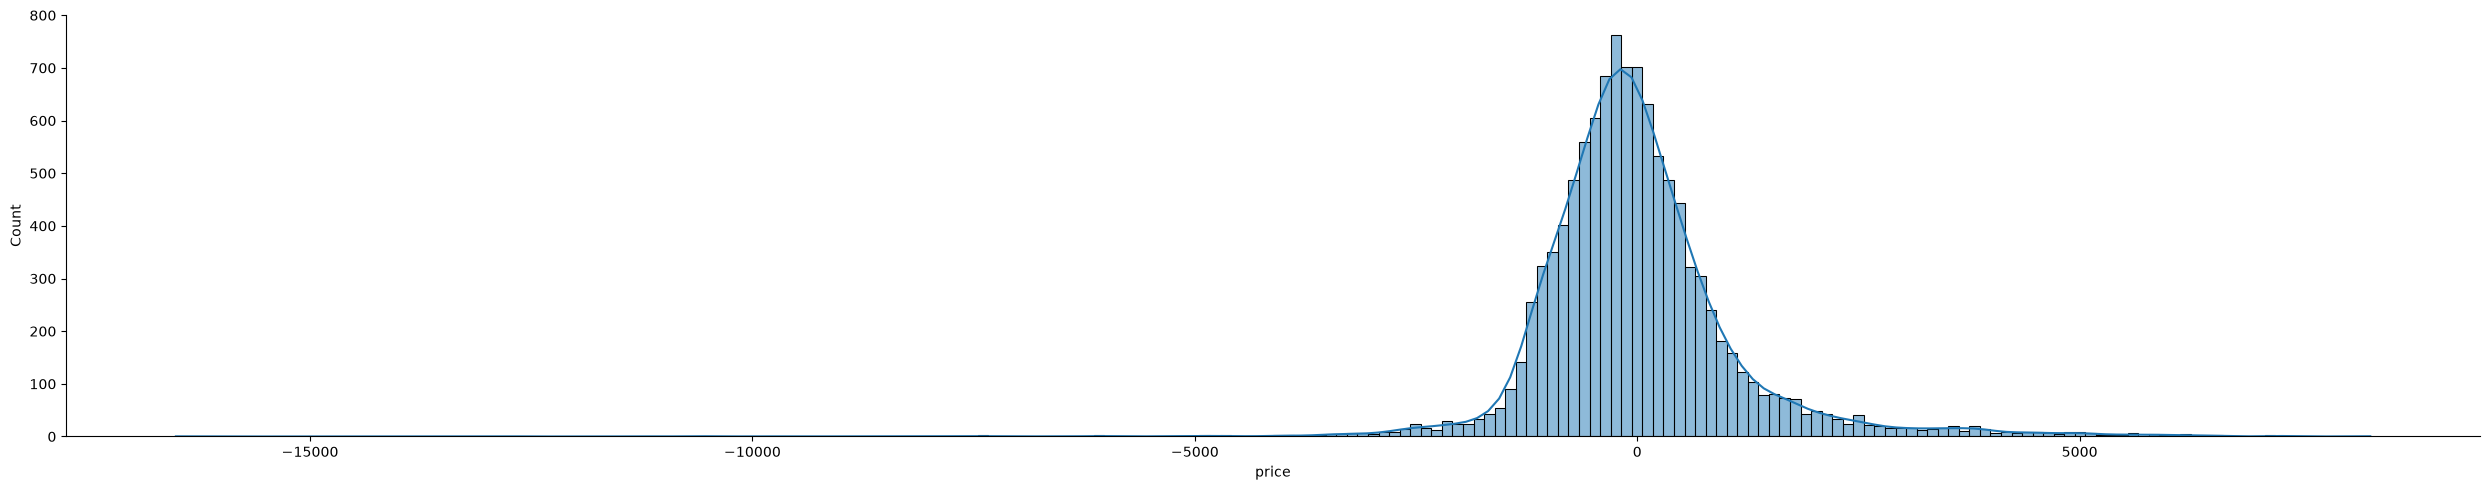

In [54]:
sns.displot(y_test - y_pred, kde=True, aspect=5);

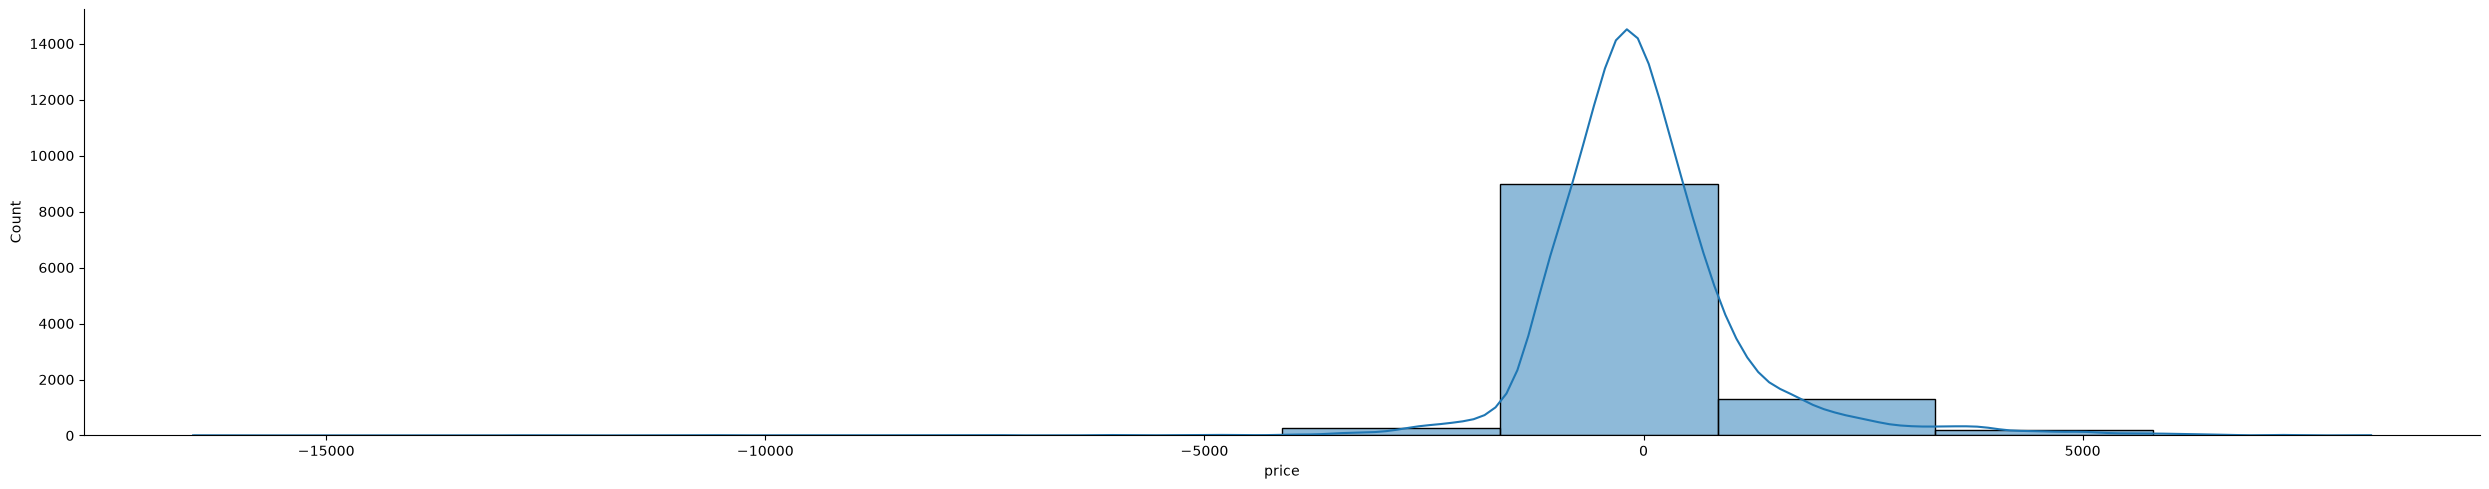

In [55]:
sns.displot(y_test - y_pred, kde=True, aspect=5, bins=10);

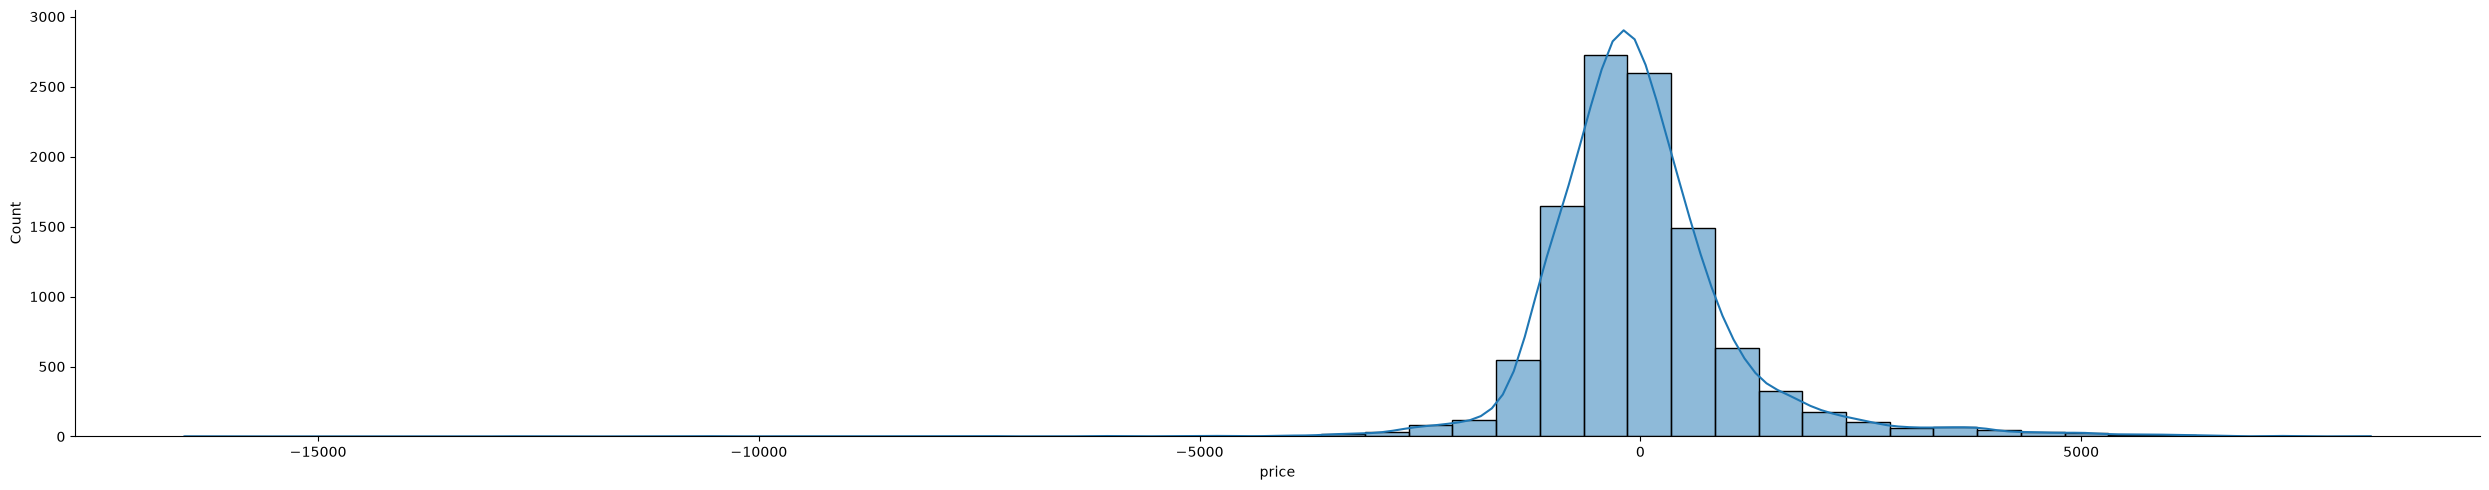

In [56]:
sns.displot(y_test - y_pred, kde=True, aspect=5, bins=50);

In [59]:
df1 = pd.DataFrame({
    'a': [1, 2, 3],
    'b': [100, 200, 300]
})
df2 = pd.DataFrame({
    'a': [1, 2, 4],
    'b': [100, 200, 400]
})
display(df1)
sc1 = StandardScaler()
sc1.fit(df1) # calculate mean and std for each column
display(f"mean: {sc1.mean_}, std: {sc1.scale_}")
df1_scaled = sc1.transform(df1) # (x - mean) / std
df1_scaled = pd.DataFrame(df1_scaled, columns=df1.columns)
display(df1_scaled)
df2_scaled = sc1.transform(df2) # use mean and std from df1 to scale df2
df2_scaled = pd.DataFrame(df2_scaled, columns=df2.columns)
display(df2_scaled)
 

,a,b
0,1,100
1,2,200
2,3,300


'mean: [  2. 200.], std: [ 0.81649658 81.64965809]'

,a,b
0,-1.224745,-1.224745
1,0.000000,0.000000
2,1.224745,1.224745


,a,b
0,-1.224745,-1.224745
1,0.000000,0.000000
2,2.449490,2.449490
